# Model Training - Approach A: Keypoint Detection

**Team Member:** Annalena Salchegger

This notebook trains a keypoint detection model to predict head and tail positions for animal orientation.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from pathlib import Path
import random
from tqdm.notebook import tqdm
import torchvision
import torchvision.transforms
import matplotlib.pyplot as plt

### Deleting old model


In [3]:
import os
old_model = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models/best_keypoint_model.pth')
if old_model.exists():
    os.remove(old_model)
    print("Deleted old model weights")

Deleted old model weights


## Configuration

In [ ]:
DATA_DIR     = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset')
PROCESSED_DIR = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed')
LABELS_DIR   = PROCESSED_DIR / 'labels_keypoints'

TRAIN_IMG    = DATA_DIR / 'images' / 'train'
VAL_IMG      = DATA_DIR / 'images' / 'val'
TRAIN_LABELS = LABELS_DIR / 'train'
VAL_LABELS   = LABELS_DIR / 'val'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

IMG_SIZE = 256
BATCH_SIZE = 8
NUM_EPOCHS = 50 # increased from 20 to 50 
LEARNING_RATE = 1e-4
NUM_KEYPOINTS = 2  # head and tail
WARMUP_EPOCHS  = 2 # epochs to train only the head before unfreezing backbone

Using device: cuda


Total training animals:  246
Mean head-tail dist:     0.0196
Median head-tail dist:   0.0174
% with dist < 0.05:      98.4%
% with dist < 0.02:      70.7%


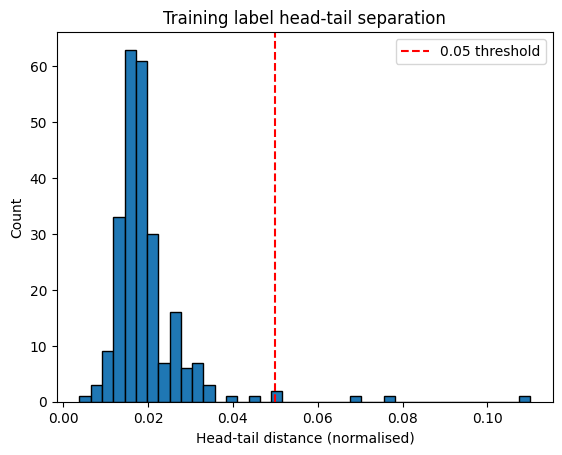

In [ ]:
# diagnostic: check head-tail distance distribution in training labels

distances = []
for label_file in TRAIN_LABELS.glob('*.txt'):
    with open(label_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 11:
                head = np.array([float(parts[5]), float(parts[6])])
                tail = np.array([float(parts[8]), float(parts[9])])
                distances.append(np.linalg.norm(head - tail))

print(f"Total training animals:  {len(distances)}")
print(f"Mean head-tail dist:     {np.mean(distances):.4f}")
print(f"Median head-tail dist:   {np.median(distances):.4f}")
print(f"% with dist < 0.05:      {sum(d < 0.05 for d in distances)/len(distances)*100:.1f}%")
print(f"% with dist < 0.02:      {sum(d < 0.02 for d in distances)/len(distances)*100:.1f}%")

plt.hist(distances, bins=40, edgecolor='black')
plt.xlabel('Head-tail distance (normalised)')
plt.ylabel('Count')
plt.title('Training label head-tail separation')
plt.axvline(x=0.05, color='red', linestyle='--', label='0.05 threshold')
plt.legend()
plt.show()

## Dataset

In [ ]:
# dataset class to load images and keypoint labels
class KeypointDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir   = Path(img_dir)
        self.label_dir = Path(label_dir)
        self.transform = transform
        
        self.samples = []
        for label_file in sorted(self.label_dir.glob('*.txt')):
            img_file = self.img_dir / f"{label_file.stem}.jpg"
            if not img_file.exists():
                for split in ['train', 'val', 'test']:
                    candidate = self.img_dir.parent / split / f"{label_file.stem}.jpg"
                    if candidate.exists():
                        img_file = candidate
                        break
                else:
                    continue

            with open(label_file) as f:
                for i, line in enumerate(f):
                    parts = line.strip().split()
                    if len(parts) >= 11:
                        self.samples.append((img_file, label_file, i))

        print(f"  Found {len(self.samples)} animal samples in {label_dir}")

    # return total number of samples
    def __len__(self):
        return len(self.samples)

    # for each sample, load the image, crop around the animal with padding, and return the cropped image and normalized keypoints
    def __getitem__(self, idx):
        img_file, label_file, animal_idx = self.samples[idx]
        
        img = Image.open(img_file).convert('RGB')
        orig_w, orig_h = img.size
        
        keypoints = torch.zeros(4, dtype=torch.float32)
        with open(label_file) as f:
            for i, line in enumerate(f):
                if i == animal_idx:
                    parts = line.strip().split()
                    if len(parts) >= 11:
                        # Crop around bbox with padding
                        cx, cy = float(parts[1]), float(parts[2])
                        bw, bh = float(parts[3]), float(parts[4])
                        pad = 0.5

                        x1 = max(0.0, (cx - bw/2 - bw*pad)) * orig_w
                        y1 = max(0.0, (cy - bh/2 - bh*pad)) * orig_h
                        x2 = min(1.0, (cx + bw/2 + bw*pad)) * orig_w
                        y2 = min(1.0, (cy + bh/2 + bh*pad)) * orig_h

                        min_crop_px = orig_w * 0.10
                        if (x2 - x1) < min_crop_px:
                            mid_x = (x1 + x2) / 2
                            x1 = max(0, mid_x - min_crop_px / 2)
                            x2 = min(orig_w, mid_x + min_crop_px / 2)

                        min_crop_py = orig_h * 0.10    
                        if (y2 - y1) < min_crop_py:
                            mid_y = (y1 + y2) / 2
                            y1 = max(0, mid_y - min_crop_py / 2)
                            y2 = min(orig_h, mid_y + min_crop_py / 2)

                        crop_w = x2 - x1
                        crop_h = y2 - y1

                        img = img.crop((x1, y1, x2, y2))

                        head_x = max(0.0, min(1.0, (float(parts[5]) * orig_w - x1) / crop_w))
                        head_y = max(0.0, min(1.0, (float(parts[6]) * orig_h - y1) / crop_h))
                        tail_x = max(0.0, min(1.0, (float(parts[8]) * orig_w - x1) / crop_w))
                        tail_y = max(0.0, min(1.0, (float(parts[9]) * orig_h - y1) / crop_h))
                        
                        keypoints = torch.tensor(
                            [head_x, head_y, tail_x, tail_y],
                            dtype=torch.float32
                        )
                    break
        
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
        
        return img, keypoints

In [ ]:
# data augmentation: random horizontal and vertical flips with corresponding keypoint adjustments
class KeypointDatasetWithFlip(KeypointDataset):
    def __getitem__(self, idx):
        img, keypoints = super().__getitem__(idx)
        if torch.rand(1) < 0.5:
            img = transforms.functional.hflip(img)
            keypoints[0] = 1 - keypoints[0]  # head_x
            keypoints[2] = 1 - keypoints[2]  # tail_x
        if torch.rand(1) < 0.5:
            img = transforms.functional.vflip(img)
            keypoints[1] = 1 - keypoints[1]  # head_y
            keypoints[3] = 1 - keypoints[3]  # tail_y
        return img, keypoints

In [ ]:
# data augmentation for limited real data
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# load datasets
train_dataset = KeypointDatasetWithFlip(TRAIN_IMG, TRAIN_LABELS, transform=train_transform)
val_dataset   = KeypointDataset(VAL_IMG,   VAL_LABELS,   transform=val_transform)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# warn if suspiciously empty
if len(train_dataset) == 0:
    raise RuntimeError("No training samples found! Check TRAIN_IMG and TRAIN_LABELS paths.")
if len(val_dataset) == 0:
    raise RuntimeError("No validation samples found! Check VAL_IMG and VAL_LABELS paths.")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

  Found 246 animal samples in /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/train
  Found 52 animal samples in /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val
Training samples:   246
Validation samples: 52


In [ ]:
# sanity check before training

print("=== Path check ===")
print(f"TRAIN_IMG exists:    {TRAIN_IMG.exists()}  ({TRAIN_IMG})")
print(f"VAL_IMG exists:      {VAL_IMG.exists()}  ({VAL_IMG})")
print(f"TRAIN_LABELS exists: {TRAIN_LABELS.exists()}  ({TRAIN_LABELS})")
print(f"VAL_LABELS exists:   {VAL_LABELS.exists()}  ({VAL_LABELS})")

print("\n=== Sample batch check ===")
imgs, kps = next(iter(train_loader))
print(f"Image batch shape:    {imgs.shape}")
print(f"Keypoints batch shape:{kps.shape}")
print(f"Keypoints sample:     {kps[0]}")
print(f"All zeros in batch?   {(kps == 0).all().item()}  <- should be False")

=== Path check ===
TRAIN_IMG exists:    True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/images/train)
VAL_IMG exists:      True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/images/val)
TRAIN_LABELS exists: True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/train)
VAL_LABELS exists:   True  (/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val)

=== Sample batch check ===
Image batch shape:    torch.Size([8, 3, 256, 256])
Keypoints batch shape:torch.Size([8, 4])
Keypoints sample:     tensor([0.5204, 0.4488, 0.5414, 0.5997])
All zeros in batch?   False  <- should be False


## Model

In [ ]:
# sanity check model forward pass
class KeypointModel(nn.Module):
    def __init__(self, num_keypoints=2):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
        self.backbone.classifier = nn.Sequential(
            nn.Linear(576, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_keypoints * 2)
        )

    def forward(self, x):
        return torch.sigmoid(self.backbone(x))

model = KeypointModel(NUM_KEYPOINTS).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,001,380


## Training

In [ ]:
def keypoint_loss(outputs, targets):
    coord_loss = nn.functional.mse_loss(outputs, targets)

    pred_vec = outputs[:, :2] - outputs[:, 2:]
    true_vec = targets[:, :2] - targets[:, 2:]

    # stabilise cosine similarity, skipped when vector norm is too small
    pred_norm = torch.norm(pred_vec, dim=1, keepdim=True).clamp(min=1e-6)
    true_norm = torch.norm(true_vec, dim=1, keepdim=True).clamp(min=1e-6)
    cos_sim   = (pred_vec / pred_norm * true_vec / true_norm).sum(dim=1)
    orient_loss = (1 - cos_sim).mean()

    # separation loss, penalises head/tail distance being wrong
    pred_dist = torch.norm(pred_vec, dim=1)
    true_dist = torch.norm(true_vec, dim=1)
    sep_loss  = nn.functional.mse_loss(pred_dist, true_dist)

    return coord_loss + 0.1 * orient_loss + 0.1 * sep_loss

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10)

# freeze backbone for warmup epochs so the new head stabilises first
print(f"Freezing backbone for first {WARMUP_EPOCHS} warmup epochs...")
for param in model.backbone.parameters():
    param.requires_grad = False
# keep the new head trainable
for param in model.backbone.classifier.parameters():
    param.requires_grad = True

Freezing backbone for first 2 warmup epochs...


In [ ]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    
    for imgs, keypoints in loader:
        imgs = imgs.to(device)
        keypoints = keypoints.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)           
        loss = keypoint_loss(outputs, keypoints)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # stability
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

# validation loop without backprop, to monitor performance and adjust learning rate
def validate(model, loader, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for imgs, keypoints in loader:
            imgs = imgs.to(device)
            keypoints = keypoints.to(device)
            outputs = model(imgs)
            loss = keypoint_loss(outputs, keypoints)
            total_loss += loss.item()
    
    return total_loss / len(loader)

In [13]:
print(val_dataset.samples[0])  # should show 3 values: (img, label, animal_idx)

(PosixPath('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/images/train/115_5577.jpg'), PosixPath('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val/115_5577.txt'), 0)


In [ ]:
# check what loss a dumb baseline gets
dummy_preds = torch.full((len(val_dataset), 4), 0.5)  # predict center for everything
dummy_targets = torch.stack([val_dataset[i][1] for i in range(len(val_dataset))])

baseline_loss = nn.functional.mse_loss(dummy_preds, dummy_targets)
print(f"Baseline loss (always predict 0.5): {baseline_loss:.4f}")

# check target distribution
print(f"\nTarget statistics:")
print(f"  Mean: {dummy_targets.mean(dim=0)}")
print(f"  Std:  {dummy_targets.std(dim=0)}")
print(f"  Min:  {dummy_targets.min(dim=0).values}")
print(f"  Max:  {dummy_targets.max(dim=0).values}")

# check a few actual samples
print(f"\nSample keypoints from val set:")
for i in range(5):
    _, kp = val_dataset[i]
    print(f"  {kp.numpy()}")

Baseline loss (always predict 0.5): 0.0256

Target statistics:
  Mean: tensor([0.5222, 0.5331, 0.5637, 0.5018])
  Std:  tensor([0.1401, 0.1835, 0.1357, 0.1646])
  Min:  tensor([0.3333, 0.0000, 0.3449, 0.0000])
  Max:  tensor([1., 1., 1., 1.])

Sample keypoints from val set:
  [0.48186687 0.39693546 0.64893687 0.6065355 ]
  [0.34410125 0.39439204 0.59966123 0.58271205]
  [0.62209845 0.         0.6575484  0.        ]
  [0.458725  0.3597711 0.522535  0.5086611]
  [0.48408735 0.53990185 0.54789734 0.44064188]


In [ ]:
# look at the raw label file content
label_file = val_dataset.samples[0][1]
print(f"File: {label_file}")
print(f"\nRaw content:")
with open(label_file) as f:
    for line in f:
        print(f"  {line.strip()}")
        parts = line.strip().split()
        if len(parts) >= 11:
            print(f"    class={parts[0]}")
            print(f"    bbox:  cx={parts[1]}, cy={parts[2]}, w={parts[3]}, h={parts[4]}")
            print(f"    head:  x={parts[5]}, y={parts[6]}, vis={parts[7]}")
            print(f"    tail:  x={parts[8]}, y={parts[9]}, vis={parts[10]}")

File: /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset/processed/labels_keypoints/val/115_5577.txt

Raw content:
  28 0.3876953125 0.200439453125 0.03515625 0.03564453125 0.385882 0.190133 1 0.402589 0.211093 1
    class=28
    bbox:  cx=0.3876953125, cy=0.200439453125, w=0.03515625, h=0.03564453125
    head:  x=0.385882, y=0.190133, vis=1
    tail:  x=0.402589, y=0.211093, vis=1


In [ ]:
# training loop with validation and model checkpointing
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

MODEL_DIR = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for epoch in range(NUM_EPOCHS):

    # unfreeze backbone after warmup and lower LR
    if epoch == WARMUP_EPOCHS:
        print(f"\nEpoch {epoch+1}: Unfreezing backbone with lower LR...")
        for param in model.backbone.parameters():
            param.requires_grad = True
        for g in optimizer.param_groups:
            g['lr'] = LEARNING_RATE * 0.1

    train_loss = train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss   = validate(model, val_loader, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_DIR / 'best_keypoint_model_A.pth')
        print(f"  -> Saved best model!")

Epoch 1/50 - Train Loss: 0.1312, Val Loss: 0.1350
  -> Saved best model!
Epoch 2/50 - Train Loss: 0.1351, Val Loss: 0.1348
  -> Saved best model!

Epoch 3: Unfreezing backbone with lower LR...
Epoch 3/50 - Train Loss: 0.1227, Val Loss: 0.1322
  -> Saved best model!
Epoch 4/50 - Train Loss: 0.1338, Val Loss: 0.1383
Epoch 5/50 - Train Loss: 0.1354, Val Loss: 0.1433
Epoch 6/50 - Train Loss: 0.1341, Val Loss: 0.1430
Epoch 7/50 - Train Loss: 0.1355, Val Loss: 0.1440
Epoch 8/50 - Train Loss: 0.1255, Val Loss: 0.1437
Epoch 9/50 - Train Loss: 0.1331, Val Loss: 0.1424
Epoch 10/50 - Train Loss: 0.1255, Val Loss: 0.1391
Epoch 11/50 - Train Loss: 0.1402, Val Loss: 0.1351
Epoch 12/50 - Train Loss: 0.1336, Val Loss: 0.1346
Epoch 13/50 - Train Loss: 0.1380, Val Loss: 0.1326
Epoch 14/50 - Train Loss: 0.1324, Val Loss: 0.1310
  -> Saved best model!
Epoch 15/50 - Train Loss: 0.1284, Val Loss: 0.1305
  -> Saved best model!
Epoch 16/50 - Train Loss: 0.1265, Val Loss: 0.1306
Epoch 17/50 - Train Loss: 0.130

#### Check if it actually trained

In [ ]:
model.eval()
total_model_loss = 0
total_baseline_loss = 0

with torch.no_grad():
    for imgs, kps in val_loader:
        imgs = imgs.to(DEVICE)
        kps  = kps.to(DEVICE)
        
        preds = model(imgs)
        total_model_loss += nn.functional.mse_loss(preds, kps).item()
        
        baseline = kps.mean(dim=0).unsqueeze(0).expand_as(kps)
        total_baseline_loss += nn.functional.mse_loss(baseline, kps).item()

print(f"Model MSE:    {total_model_loss / len(val_loader):.4f}")
print(f"Baseline MSE: {total_baseline_loss / len(val_loader):.4f}")

# sample predictions vs targets
print("\nSample predictions vs targets:")
imgs, kps = next(iter(val_loader))
with torch.no_grad():
    preds = model(imgs.to(DEVICE)).cpu()

for i in range(5):
    p = preds[i].numpy()
    t = kps[i].numpy()
    dist_pred = np.linalg.norm(p[:2] - p[2:])
    dist_true = np.linalg.norm(t[:2] - t[2:])
    print(f"  pred: head=({p[0]:.3f},{p[1]:.3f}) tail=({p[2]:.3f},{p[3]:.3f}) dist={dist_pred:.3f}")
    print(f"  true: head=({t[0]:.3f},{t[1]:.3f}) tail=({t[2]:.3f},{t[3]:.3f}) dist={dist_true:.3f}")
    print()

Model MSE:    0.0259
Baseline MSE: 0.0194

Sample predictions vs targets:
  pred: head=(0.496,0.499) tail=(0.499,0.527) dist=0.028
  true: head=(0.482,0.397) tail=(0.649,0.607) dist=0.268

  pred: head=(0.494,0.494) tail=(0.529,0.521) dist=0.044
  true: head=(0.344,0.394) tail=(0.600,0.583) dist=0.317

  pred: head=(0.488,0.512) tail=(0.508,0.488) dist=0.031
  true: head=(0.622,0.000) tail=(0.658,0.000) dist=0.035

  pred: head=(0.503,0.508) tail=(0.493,0.511) dist=0.011
  true: head=(0.459,0.360) tail=(0.523,0.509) dist=0.162

  pred: head=(0.490,0.524) tail=(0.512,0.476) dist=0.052
  true: head=(0.484,0.540) tail=(0.548,0.441) dist=0.118



## Training Curves

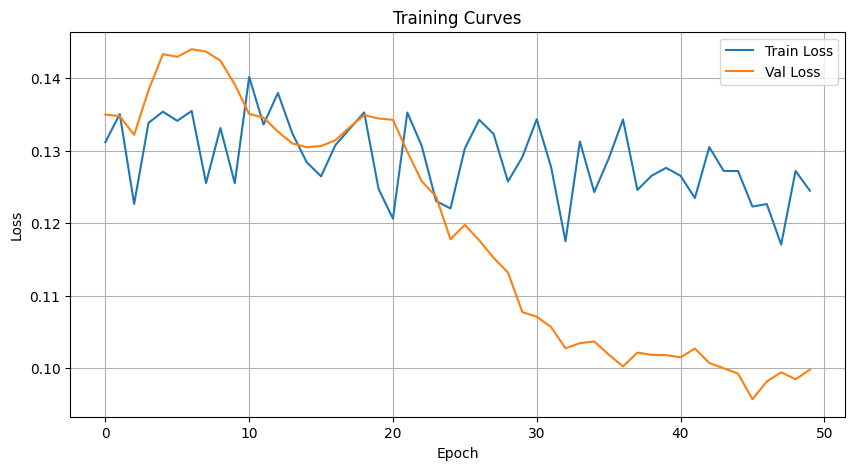

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves')
plt.legend()
plt.grid(True)
plt.show()

## Save Model

In [19]:
import os
os.makedirs('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models', exist_ok=True)
torch.save(model.state_dict(), '/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models/keypoint_model_final.pth')
print("Model saved!")

Model saved!
